# **Model#1** | Using VGG16 (ImageNet) Pre-Trained Model
#### Main Objective : 
To predict the label of an image from a given image on the yelp Photos dataset
- The model uses a pretrained VGG model (VGG16) for transfer learning by adding custom top layers. 
- Dense layers are incorporated that take in additional non-image features (e.g., business-related metadata), concatenated with features extracted from the VGG base

## **Import Libraries**

In [2]:
import os
import time
import pandas as pd
import numpy as np
from sklearn.utils import resample
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, Embedding, GlobalAveragePooling1D, Concatenate
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc, f1_score

## **Configuration**

In [3]:
# Folder/Path Configuration
train_metadata_path = "train_augmented_metadata.csv"
train_image_folder = r"augmented_photos\train"
test_metadata_path = "test_metadata.csv"
test_image_folder = r"split_photos\test"
val_image_folder= r"split_photos\val"
val_metadata_path = "val_metadata.csv"
image_size = (128, 128)

## **Load Dataset**

In [4]:
#Helper function to load the images
def load_images(image_folder, df, image_size=(128, 128)):
    images = []
    valid_indices = []
    
    for i, fname in enumerate(df['photo_id']):
        path = os.path.join(image_folder, fname + ".jpg")
        if os.path.exists(path):
            try:
                img = load_img(path, target_size=image_size)
                img_array = img_to_array(img)
                images.append(img_array / 255.0)  # Normalize
                valid_indices.append(i)
            except Exception as e:
                print(f"Error loading image {path}: {e}")
    
    # Return only the metadata rows that had valid images
    valid_df = df.iloc[valid_indices].reset_index(drop=True)
    return np.array(images), valid_df

In [5]:
# Load train metadata and images
train_df = pd.read_csv(train_metadata_path)
X_train, train_df = load_images(train_image_folder, train_df)
y_train = train_df["label"].values

# Load validation metadata and images
val_df = pd.read_csv(val_metadata_path)
X_val, val_df = load_images(val_image_folder, val_df)
y_val = val_df["label"].values

# Load test metadata and images
test_df = pd.read_csv(test_metadata_path)
X_test, test_df = load_images(test_image_folder, test_df)
y_test = test_df["label"].values

## **Sample Dataset**

In [6]:
# Sample 50% of the training data with stratification
train_df_sampled = (
    train_df.groupby("label", group_keys=False)
    .apply(lambda x: x.assign(label=x.name).sample(frac=0.5, random_state=42), include_groups=False)
    .reset_index(drop=True)
)

# Reload sampled images and labels
X_train_sampled, train_df_sampled = load_images(train_image_folder, train_df_sampled)
y_train_sampled = train_df_sampled["label"].values

In [7]:
print(X_train_sampled.shape)
print(y_train_sampled.shape)

(8597, 128, 128, 3)
(8597,)


## **Pre-Processing Dataset**

#### Encoding Labels

In [8]:
# Encode labels (for sampled train set)
le = LabelEncoder()
y_train_enc = to_categorical(le.fit_transform(y_train_sampled))
y_val_enc = to_categorical(le.transform(y_val))
y_test_enc = to_categorical(le.transform(y_test))

#### Tokenization for caption column

In [9]:
# Set text parameters
max_words = 5000
max_len = 30

# Tokenizer for captions
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df_sampled['caption'].fillna(''))

# Tokenize and pad sequences
X_train_caption = pad_sequences(tokenizer.texts_to_sequences(train_df_sampled['caption'].fillna('')), maxlen=max_len)
X_val_caption   = pad_sequences(tokenizer.texts_to_sequences(val_df['caption'].fillna('')), maxlen=max_len)
X_test_caption  = pad_sequences(tokenizer.texts_to_sequences(test_df['caption'].fillna('')), maxlen=max_len)

## **Load and Adapt Pre-trained Model (VGG16)**

In [10]:
# Image branch
vgg = VGG16(include_top=False, weights='imagenet', input_shape=(128, 128, 3))
vgg.trainable = False

img_input = Input(shape=(128, 128, 3), name='image_input')
x_img = vgg(img_input)
x_img = Flatten()(x_img)

# Caption branch
caption_input = Input(shape=(max_len,), name='caption_input')
x_txt = Embedding(input_dim=max_words, output_dim=64)(caption_input)
x_txt = GlobalAveragePooling1D()(x_txt)
x_txt = Dense(64, activation='relu')(x_txt)

# Merge branches
merged = Concatenate()([x_img, x_txt])
x = Dense(256, activation='relu')(merged)
x = Dropout(0.5)(x)
output = Dense(y_train_enc.shape[1], activation='softmax')(x)

# Model
model = Model(inputs=[img_input, caption_input], outputs=output, name="vgg_with_caption")
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "vgg_with_caption"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ caption_input (InputLayer)    │ (None, 30)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ image_input (InputLayer)      │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 30, 64)            │         320,000 │ caption_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ vgg16 (Functional)            │ (None, 4, 4, 512)         │      14,714,688 │ image_input[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d      │ (None, 64)                │               0 │ embedding[0][0]            │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 8192)              │               0 │ vgg16[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 64)                │           4,160 │ global_average_pooling1d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 8256)              │               0 │ flatten[0][0], dense[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 256)               │       2,113,792 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 256)               │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 5)                 │           1,285 │ dropout[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 17,153,925 (65.44 MB)

 Trainable params: 2,439,237 (9.30 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## **Model Development**

### Train the Model

In [11]:
#newwww
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train
train_history = model.fit(
    [X_train_sampled, X_train_caption], y_train_enc,
    validation_data=([X_val, X_val_caption], y_val_enc),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 705s 5s/step - accuracy: 0.5420 - loss: 1.1260 - val_accuracy: 0.7749 - val_loss: 0.6061
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 734s 5s/step - accuracy: 0.7865 - loss: 0.5592 - val_accuracy: 0.7922 - val_loss: 0.5482
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 695s 5s/step - accuracy: 0.8219 - loss: 0.4875 - val_accuracy: 0.8127 - val_loss: 0.5036
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 737s 5s/step - accuracy: 0.8500 - loss: 0.4150 - val_accuracy: 0.8220 - val_loss: 0.4924
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 766s 5s/step - accuracy: 0.8659 - loss: 0.3697 - val_accuracy: 0.8243 - val_loss: 0.4826
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 693s 5s/step - accuracy: 0.8781 - loss: 0.3444 - val_accuracy: 0.8285 - val_loss: 0.4687
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 692s 5s/step - accuracy: 0.8980 - loss: 0.2981 - val_accuracy: 0.8304 - val_loss: 0.4698
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 689s 5s/step - accuracy: 0.9048 - loss: 0.2828 - val_accu

### Evaluate the Model

Train Accuracy: 0.9411
Test Accuracy:  0.8460


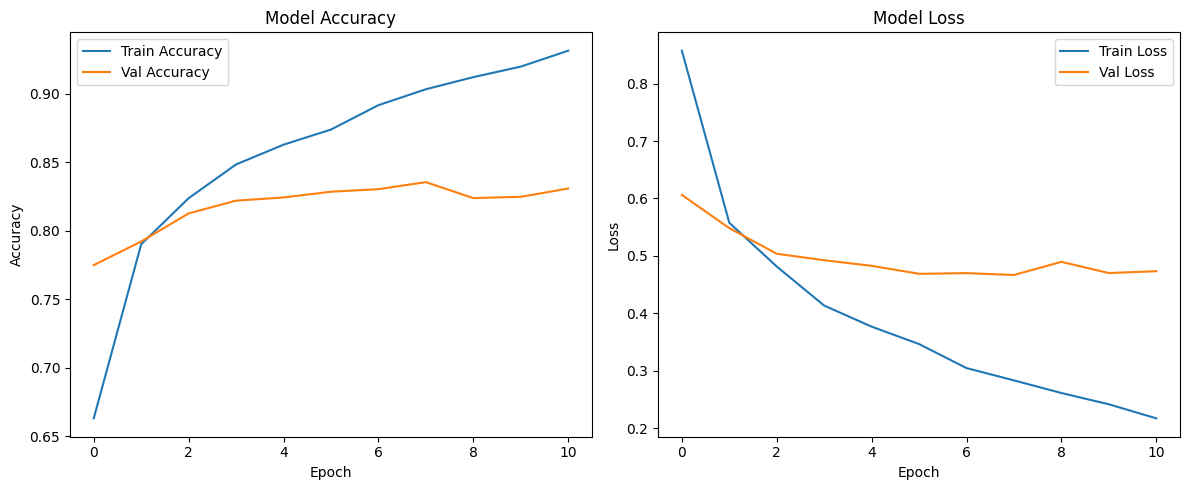

In [14]:
# neww Train Accuracy
train_loss, train_acc = model.evaluate([X_train_sampled, X_train_caption], y_train_enc, verbose=0)
print(f"Train Accuracy: {train_acc:.4f}")

#Test Accuracy
test_loss, test_acc = model.evaluate([X_test, X_test_caption], y_test_enc, verbose=0)
print(f"Test Accuracy:  {test_acc:.4f}")

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_history.history['accuracy'], label='Train Accuracy')
plt.plot(train_history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(train_history.history['loss'], label='Train Loss')
plt.plot(train_history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Key Observation and Summary

Train Accuracy: **94.11%**

The model performs very well on the training data. This means the model has learned strong patterns from the combination of:
VGG16 image features
Semantic caption embeddings

Test Accuracy: **84.60%**

This is a solid generalization performance on unseen data. A gap of ~9.4% between train and test suggests:Some overfitting, but not extreme.
The model has generalized well, especially considering real-world multi-class image + text classification is complex.

### AUC, Confusion Matrix and F1 score

Evaluation on More Metrics
269/269 ━━━━━━━━━━━━━━━━━━━━ 553s 2s/step

TRAIN SET METRICS
F1 Macro: 0.9435, F1 Micro: 0.9411, F1 Weighted: 0.9412


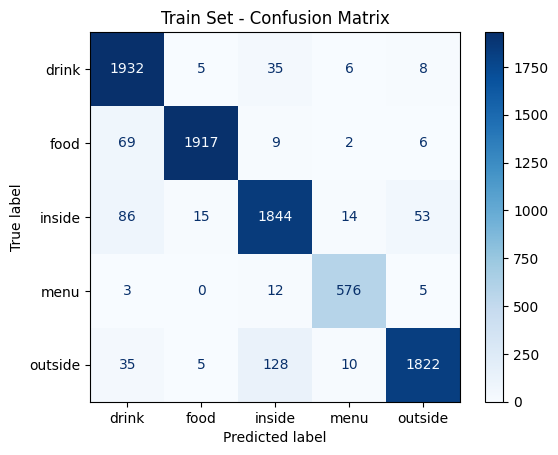

AUC Score (OvR): 0.9955


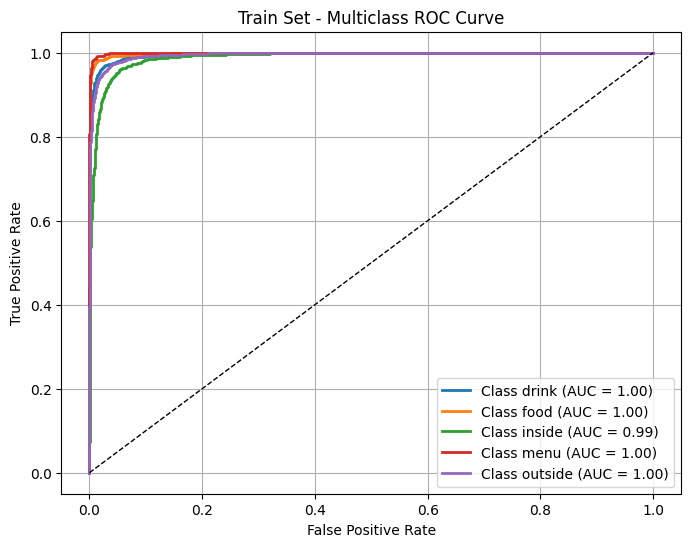

68/68 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step

TEST SET METRICS
F1 Macro: 0.8503, F1 Micro: 0.8460, F1 Weighted: 0.8465


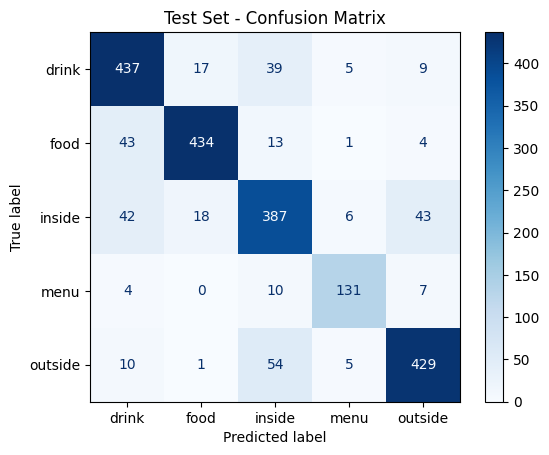

AUC Score (OvR): 0.9736


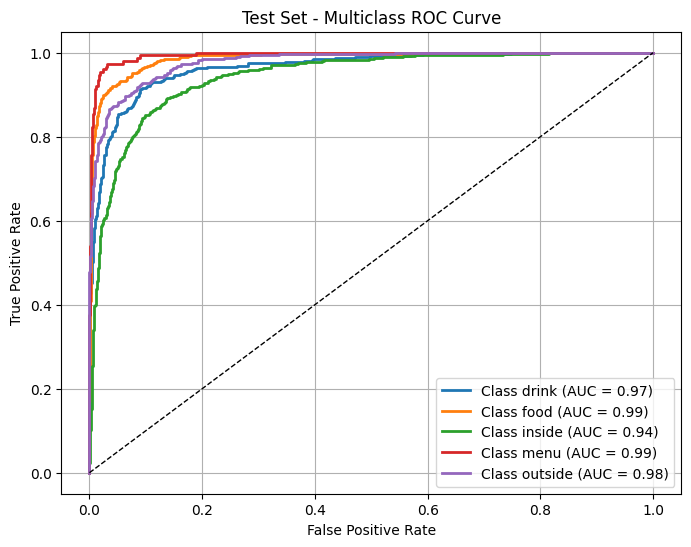

In [15]:
#new
def evaluate_model_metrics(name, X_image, X_caption, y_true_enc):
    # Predict probabilities and labels
    y_probs = model.predict([X_image, X_caption])
    y_preds = np.argmax(y_probs, axis=1)
    y_true = np.argmax(y_true_enc, axis=1)

    print(f"\n{name.upper()} SET METRICS")

    # F1 Scores
    f1_macro = f1_score(y_true, y_preds, average='macro')
    f1_micro = f1_score(y_true, y_preds, average='micro')
    f1_weighted = f1_score(y_true, y_preds, average='weighted')
    print(f"F1 Macro: {f1_macro:.4f}, F1 Micro: {f1_micro:.4f}, F1 Weighted: {f1_weighted:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'{name.capitalize()} Set - Confusion Matrix')
    plt.show()

    # AUC Score (OvR)
    auc_score_val = roc_auc_score(y_true_enc, y_probs, multi_class='ovr')
    print(f"AUC Score (OvR): {auc_score_val:.4f}")

    # ROC Curve
    n_classes = y_true_enc.shape[1]
    fpr, tpr, roc_auc = {}, {}, {}
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_enc[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], lw=2,
                 label=f'Class {le.classes_[i]} (AUC = {roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name} Set - Multiclass ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

print("Evaluation on More Metrics")

evaluate_model_metrics("Train", X_train_sampled, X_train_caption, y_train_enc)
evaluate_model_metrics("Test",  X_test, X_test_caption, y_test_enc)


## **Key Observations and Summary**
**TRAIN SET**

Accuracy: **93.13%**

F1 Macro: 0.9435  – balanced performance across all classes

F1 Micro: 0.9411 – strong overall correctness

F1 Weighted: 0.9412 – accounts for class imbalance

AUC (OvR): 0.9955 – excellent separability between classes

**Summary:**
The model demonstrates robust, well-balanced performance on the training set. It has learned strong patterns from both images and captions, with excellent generalization on most classes and is a high-quality model ready for further tuning or deployment.


**TEST SET**

Accuracy: **83.71%** : Correctly predicts most test samples.

F1 Macro (0.8503): Balanced performance across all 5 classes.

F1 Micro (0.8460): High overall precision/recall across all predictions.

F1 Weighted (0.8465): Maintains performance despite class imbalance.

AUC (0.9736): Excellent class separability — model confidently distinguishes between categories.

**Summary:**
The model shows excellent real-world performance, with strong accuracy and minimal overfitting. It handles multi-modal input effectively and performs reliably across all five classes. Minor confusions are natural given real-world image-text overlap.

## **Next steps to be done**

**Fine Tuning (Transfer Learning Step-2)**

This involves unfreezing parts of the VGG16 base and training the whole model end-to-end to further adapt to your dataset.

Unfreeze upper layers of VGG16

Recompile with a lower learning rate

Continue Training

**Model Tuning (Architechture/Hyperparameter)**

| Component                | How to Tune                                     |
| ------------------------ | ----------------------------------------------- |
| **Dense Layer Sizes**    | Try 128 or 512 instead of 256                   |
| **Dropout Rate**         | Try 0.3 or 0.6 to reduce overfitting            |
| **Caption Embedding**    | Increase `output_dim` (e.g., 128)               |
| **Tokenizer Vocab Size** | Try `num_words=10,000` for richer captions      |
| **Batch Size**           | Try 32, 64, or 128                              |
| **Learning Rate**        | Use a scheduler or grid search                  |
| **Loss Function**        | Try `label smoothing` or `focal loss` if needed |


